In [1]:
"""
XGBoost classifier trained on the 60GeV runs with bias as input feature.

Gradient-boosted-tree counterpart to CNN_Classifier_60GeV.ipynb and
MLP_Classifier_60GeV.ipynb: identical data pipeline, but the (3, 64, 38) input
is flattened to 7296 features and classified with XGBoost instead of a neural
net. Binary objective (binary:logistic); P(electron) via predict_proba.
"""


'\nXGBoost classifier trained on the 60GeV runs with bias as input feature.\n\nGradient-boosted-tree counterpart to CNN_Classifier_60GeV.ipynb and\nMLP_Classifier_60GeV.ipynb: identical data pipeline, but the (3, 38, 64) input\nis flattened to 7296 features and classified with XGBoost instead of a neural\nnet. Binary objective (binary:logistic); P(electron) via predict_proba.\n'

In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import uproot
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix


def find_project_root(marker="Data", start=None):
    """Walk up from `start` (default: cwd) until we find a directory containing `marker`."""
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find '{marker}' starting from {p}")

PROJECT_ROOT = find_project_root("Data")
DATA_DIR     = PROJECT_ROOT / "Data"
LABELS_CSV   = DATA_DIR / "runs.csv"
print("project root:", PROJECT_ROOT)


project root: /Users/prometheus/Documents/Python/ML_FoCal_FinalProject


In [3]:
# data loading
labels_df = pd.read_csv(LABELS_CSV)
# Keep only the 60 GeV runs with non-zero bias (the new e/h dataset).
runs_df = labels_df.query("energy_GeV == 60 and bias_V > 0").copy()
print("runs to load:")
print(runs_df.to_string(index=False))

def find_root_file(run, data_dir=DATA_DIR):
    """Match either RunXXXX.root or RunXXX_EventMatch.root naming."""
    candidates = list(data_dir.glob(f"Run{run}*.root")) + list(data_dir.glob(f"Run{run:04d}*.root"))
    if not candidates:
        raise FileNotFoundError(f"No ROOT file for run {run}")
    return candidates[0]

val_chunks, run_ids, parts, biases = [], [], [], []
for _, row in runs_df.iterrows():
    f = find_root_file(int(row["run"]))
    t = uproot.open(f)["data_tree"]
    n = t.num_entries

    a0 = t["val0_list_0"].array(library="np").reshape(-1, 64, 38)
    a1 = t["val0_list_1"].array(library="np").reshape(-1, 64, 38)
    val_chunks.append(np.stack([a0, a1], axis=1))

    run_ids.append(np.full(n, int(row["run"]),     dtype=np.int32))
    parts.append(  np.full(n, row["particle"],     dtype="U1"))
    biases.append( np.full(n, int(row["bias_V"]),  dtype=np.int32))
    print(f"  Run{row.run:03d}: {n:6d} events  ({row.particle}, {row.bias_V}V)")

val0     = np.concatenate(val_chunks, axis=0)
run_id   = np.concatenate(run_ids)
particle = np.concatenate(parts)
bias_v   = np.concatenate(biases)
del val_chunks, run_ids, parts, biases

print(f"\ntotal events: {val0.shape[0]}  shape: {val0.shape}  ({val0.nbytes / 1e9:.2f} GB)")


runs to load:
 run  energy_GeV particle  bias_V
 577          60        h      43
 578          60        h      43
 579          60        h      45
 580          60        h      45
 603          60        e      45
 604          60        e      45
 605          60        e      43
 606          60        e      43
 607          60        e      43
  Run577:  17621 events  (h, 43V)
  Run578:  22362 events  (h, 43V)
  Run579:  20390 events  (h, 45V)
  Run580:  19992 events  (h, 45V)
  Run603:   3432 events  (e, 45V)
  Run604:  10275 events  (e, 45V)
  Run605:  17010 events  (e, 43V)
  Run606:  18581 events  (e, 43V)
  Run607:  17227 events  (e, 43V)

total events: 146890  shape: (146890, 2, 64, 38)  (2.86 GB)


### Data shape

Loaded as `val0` with shape `(N, 2, 64, 38)`:

| Dim | Size | Meaning |
|-----|------|---------|
| 0   | N    | event index (one event = one trigger) |
| 1   | 2    | detector halves: `h0`, `h1` |
| 2   | 64   | chips per half |
| 3   | 38   | readout channels per chip |

Parallel label arrays of length N: `run_id`, `particle` (`'e'`/`'h'`), `bias_v` (43/45).

The bias channel that turns this into `(N, 3, 64, 38)` is added later, after pedestal normalization, before training.


val0 shape: (146890, 2, 64, 38)  dtype: uint32
value range: 0 .. 1023
mean: 102.0  nonzero fraction: 0.974

events per (particle, bias):
                 n_events  n_runs
particle bias_V                  
e        43         52818       3
         45         13707       2
h        43         39983       2
         45         40382       2


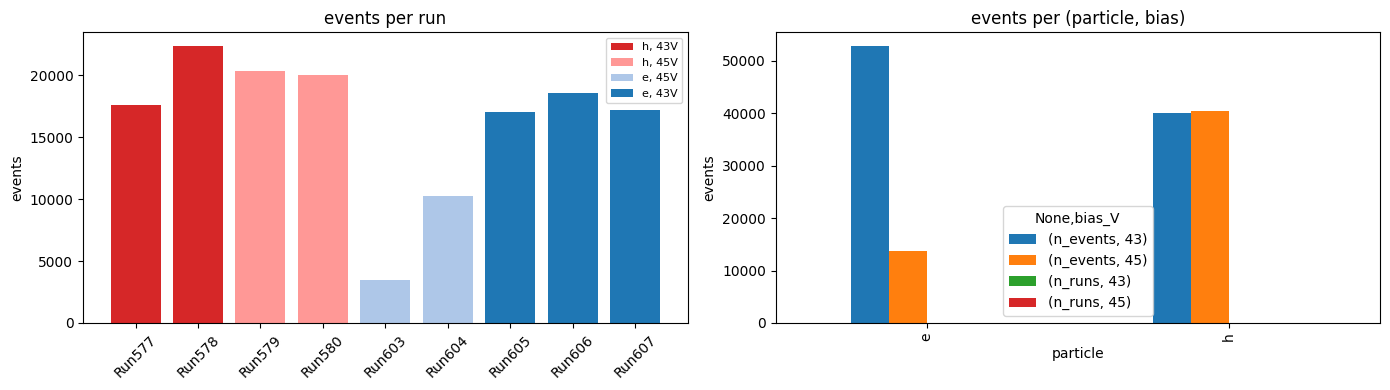

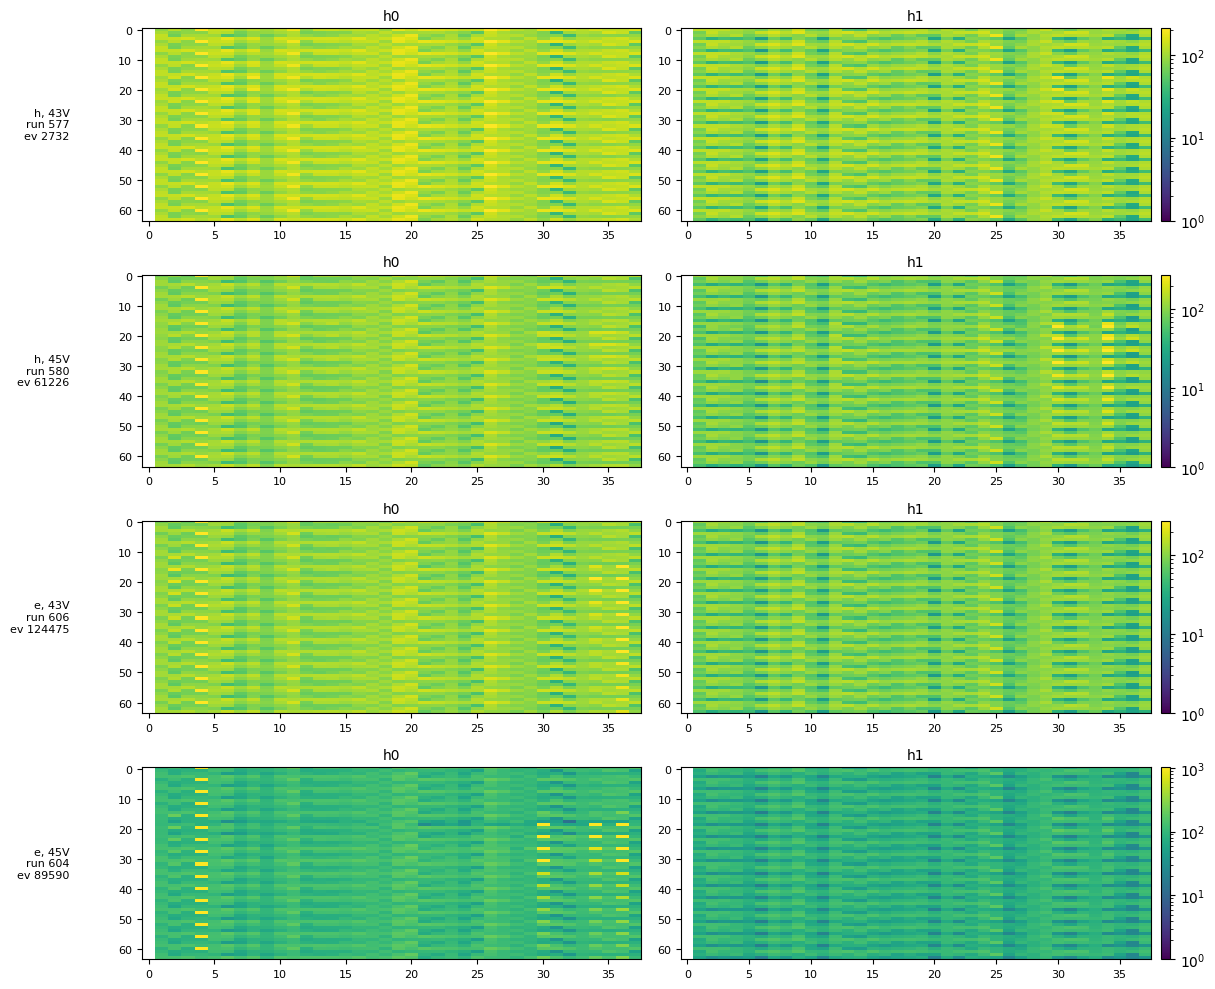

In [6]:
# Visualisation of the data (size and type and so on)
print(f"val0 shape: {val0.shape}  dtype: {val0.dtype}")
print(f"value range: {val0.min()} .. {val0.max()}")
print(f"mean: {val0.mean():.1f}  nonzero fraction: {(val0 > 0).mean():.3f}")

# Counts per (particle, bias) cell
summary = (pd.DataFrame({"particle": particle, "bias_V": bias_v, "run": run_id})
           .groupby(["particle", "bias_V"])
           .agg(n_events=("run", "size"), n_runs=("run", "nunique")))
print("\nevents per (particle, bias):")
print(summary)

# Bar chart: events per run, colored by (particle, bias)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df = pd.DataFrame({"run": run_id, "particle": particle, "bias_V": bias_v})
counts = df.groupby(["run", "particle", "bias_V"]).size().reset_index(name="n")
colors = {("e", 43): "#1f77b4", ("e", 45): "#aec7e8",
          ("h", 43): "#d62728", ("h", 45): "#ff9896"}
for (_, row), x in zip(counts.iterrows(), range(len(counts))):
    ax[0].bar(x, row.n, color=colors[(row.particle, row.bias_V)],
              label=f"{row.particle}, {row.bias_V}V")
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels([f"Run{r:03d}" for r in counts.run], rotation=45)
ax[0].set_ylabel("events"); ax[0].set_title("events per run")
# Dedupe legend
handles, labels = ax[0].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels): seen.setdefault(l, h)
ax[0].legend(seen.values(), seen.keys(), fontsize=8)

# Stacked: events per (particle, bias)
summary.unstack("bias_V").plot.bar(ax=ax[1], stacked=False)
ax[1].set_ylabel("events"); ax[1].set_title("events per (particle, bias)")
plt.tight_layout(); plt.show()

# One example event per (particle, bias) cell -- both halves
from matplotlib.colors import LogNorm
groups = [("h", 43), ("h", 45), ("e", 43), ("e", 45)]
fig, ax = plt.subplots(len(groups), 2, figsize=(12, 2.5 * len(groups)), squeeze=False)
rng = np.random.RandomState(0)
for gi, (p, b) in enumerate(groups):
    mask = (particle == p) & (bias_v == b)
    idx  = rng.choice(np.where(mask)[0])
    ev   = val0[idx]
    vmax = max(int(np.percentile(ev, 99.5)), 2)
    for h in range(2):
        im = ax[gi, h].imshow(ev[h], aspect="auto", cmap="viridis",
                              norm=LogNorm(vmin=1, vmax=vmax))
        ax[gi, h].set_title(f"h{h}", fontsize=10)
        ax[gi, h].tick_params(labelsize=8)
    plt.colorbar(im, ax=ax[gi, 1], fraction=0.04, pad=0.02)
    ax[gi, 0].set_ylabel(f"{p}, {b}V\nrun {run_id[idx]}\nev {idx}",
                         rotation=0, ha="right", va="center", labelpad=35, fontsize=8)
plt.tight_layout(); plt.subplots_adjust(left=0.10); plt.show()


In [7]:
""" Pedestal normalization (computed separately per bias voltage)
For each bias, take the quietest 50% of events by total ADC -- those are mostly noise/pedestal events. 
Use them to compute per-channel mean and std. Apply z-score normalization to all events of that bias.
"""

event_sum = val0.sum(axis=(1, 2, 3))

pedestals = {}  # bias -> (mean (2,64,38), std (2,64,38))
for b in np.unique(bias_v):
    in_bias = bias_v == b
    cutoff  = np.percentile(event_sum[in_bias], 50)
    quiet   = in_bias & (event_sum < cutoff)
    mean    = val0[quiet].mean(axis=0).astype(np.float32)
    std     = val0[quiet].std(axis=0).astype(np.float32)
    pedestals[int(b)] = (mean, std)
    print(f"bias {b}V: {quiet.sum():6d} quiet events used  "
          f"mean ADC {mean.min():.1f}..{mean.max():.1f}  "
          f"avg std {std.mean():.2f}")

# Apply normalization (in place per-bias slice to avoid building a 2x-size copy)
val0_norm = np.empty(val0.shape, dtype=np.float32)
for b, (mean, std) in pedestals.items():
    m = bias_v == b
    val0_norm[m] = (val0[m].astype(np.float32) - mean) / (std + 1e-3)

print(f"\nnormalized: shape={val0_norm.shape}  dtype={val0_norm.dtype}  "
      f"memory={val0_norm.nbytes / 1e9:.2f} GB")
print(f"mean: {val0_norm.mean():+.3f}  (should be ~0 since most events are quiet)")
print(f"std : {val0_norm.std():.3f}  (close to 1 if normalization is sane)")


bias 43V:  46394 quiet events used  mean ADC 0.0..1023.0  avg std 3.14
bias 45V:  27042 quiet events used  mean ADC 0.0..1023.0  avg std 5.27

normalized: shape=(146890, 2, 64, 38)  dtype=float32  memory=2.86 GB
mean: +0.059  (should be ~0 since most events are quiet)
std : 1.229  (close to 1 if normalization is sane)


In [8]:
"""
Build the model input matrix and 3-way train / val / test split.

Input: the (N, 3, 64, 38) tensor (2 normalized halves + 1 broadcast bias
channel), flattened to a (N, 7296) feature matrix for XGBoost. The (3, 64, 38)
view is kept as `x_img` so SHAP attributions can be reshaped onto the detector
geometry later. Labels: int (N,), 0 = hadron, 1 = electron.

Splits stratified on (particle, bias): train 70% / val 15% / test 15%.
"""

# 3-channel input: 2 normalized halves + 1 bias channel
bias_norm = (bias_v.astype(np.float32) - 44.0)  # 43 -> -1, 45 -> +1
bias_ch   = np.broadcast_to(bias_norm[:, None, None, None],
                            (len(val0_norm), 1, 64, 38)).astype(np.float32)
x_img = np.concatenate([val0_norm, bias_ch], axis=1)         # (N, 3, 64, 38)
X     = x_img.reshape(len(x_img), -1)                        # (N, 7296)
y     = (particle == "e").astype(np.int64)

print(f"X: {X.shape}  {X.nbytes / 1e9:.2f} GB")
print(f"y: {y.shape}  label counts: {dict(zip(['h', 'e'], np.bincount(y)))}")

# Stratify on (particle, bias) so each cell is represented in all splits
strat = np.array([f"{p}_{b}" for p, b in zip(particle, bias_v)])

idx_trainval, idx_test = train_test_split(
    np.arange(len(X)), test_size=0.15, stratify=strat, random_state=0)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.15 / 0.85, stratify=strat[idx_trainval], random_state=0)
print(f"\nsplit sizes:  train {len(idx_train)}  val {len(idx_val)}  test {len(idx_test)}")
for name, idx in [("  train", idx_train), ("  val  ", idx_val), ("  test ", idx_test)]:
    counts = {k: int((strat[idx] == k).sum()) for k in sorted(np.unique(strat))}
    print(f"{name}: {counts}")

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]   # set aside, do not peek


X: (146890, 7296)  4.29 GB
y: (146890,)  label counts: {'h': np.int64(80365), 'e': np.int64(66525)}

split sizes:  train 102822  val 22034  test 22034
  train: {np.str_('e_43'): 36972, np.str_('e_45'): 9595, np.str_('h_43'): 27988, np.str_('h_45'): 28267}
  val  : {np.str_('e_43'): 7923, np.str_('e_45'): 2056, np.str_('h_43'): 5997, np.str_('h_45'): 6058}
  test : {np.str_('e_43'): 7923, np.str_('e_45'): 2056, np.str_('h_43'): 5998, np.str_('h_45'): 6057}


### XGBoost classifier configuration

A gradient-boosted tree ensemble on the 7296 flattened features. Like the MLP it
has no notion of spatial locality — every channel/chip/strip is an independent
column the trees can split on.

- **`objective="binary:logistic"`** — outputs P(electron); the tree analogue of
  the NN's single-logit + sigmoid head.
- **`n_estimators=2000` + `early_stopping_rounds=30`** — boost until val logloss
  stops improving for 30 rounds, keep the best iteration.
- **`learning_rate=0.05`**, **`max_depth=6`**, **`min_child_weight=5`**,
  **`reg_lambda`** — step size and complexity control.
- **`subsample` / `colsample_bytree`** — row/column subsampling; with 7296
  mostly-quiet features, sampling half the columns per tree fights overfitting
  and speeds training.
- **`importance_type="gain"`** — feature importances reported as total split gain
  (used in the interpretability cell).

In [9]:
clf = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.5,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=30,
    importance_type="gain",
    tree_method="hist",
    n_jobs=-1,
    random_state=0,
)
print(clf)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type='gain',
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=-1,
              num_parallel_tree=None, ...)


### Training

`fit` on the train split with the val split as the early-stopping watch set.
XGBoost reports val logloss each round and keeps the best iteration. The booster
is cached to `Rasmus/Classifier/XGB_classifier_60GeV.json` (alongside the CNN/MLP `.pt`
caches); set `RETRAIN = True` to refit. No test-set access here.

In [10]:
RETRAIN = False
CLASSIFIER_WEIGHTS = PROJECT_ROOT / "Rasmus" / "Classifier" / "XGB_classifier_60GeV.json"

history = None  # filled with evals_result() when we actually train

if CLASSIFIER_WEIGHTS.exists() and not RETRAIN:
    clf.load_model(CLASSIFIER_WEIGHTS)
    print(f"loaded cached model from {CLASSIFIER_WEIGHTS.name} (set RETRAIN=True to override)")
else:
    clf.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=50,
    )
    history = clf.evals_result()
    clf.save_model(CLASSIFIER_WEIGHTS)
    print(f"\nbest iteration: {clf.best_iteration}  best val logloss: {clf.best_score:.4f}")
    print(f"saved {CLASSIFIER_WEIGHTS}")


loaded cached model from XGB_classifier_60GeV.json (set RETRAIN=True to override)


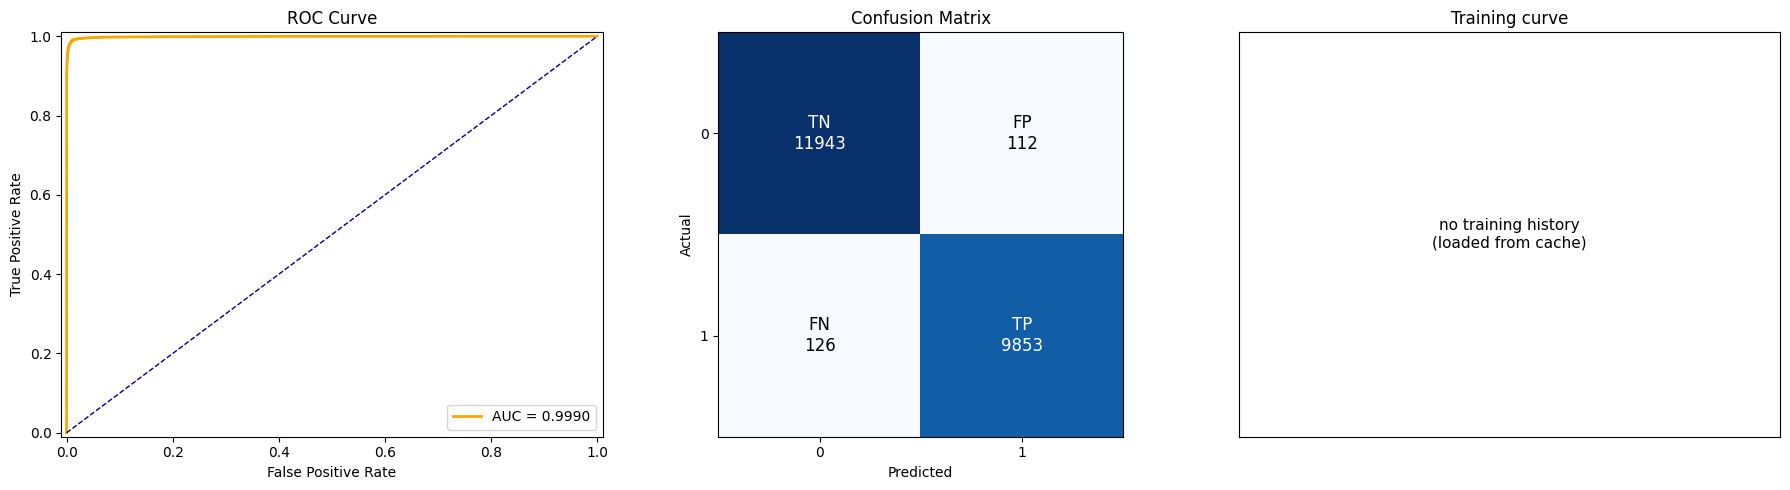

val accuracy:  0.9892
val AUC:       0.9990
confusion matrix (rows=actual, cols=predicted):
      pred=h  pred=e
act=h   11943     112
act=e     126    9853


In [11]:
"""
Evaluate the trained classifier on the validation set.

ROC + AUC, confusion matrix, and the training curve (val logloss per boosting
round). Plus a printed summary: val accuracy, AUC, and the raw confusion matrix.
"""

y_true = y_val
y_prob = clf.predict_proba(X_val)[:, 1]   # P(electron)
y_pred = (y_prob > 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = auc(fpr, tpr)
cm          = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC ---
ax[0].plot(fpr, tpr, color="orange", lw=2, label=f"AUC = {roc_auc:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve"); ax[0].legend(loc="lower right")
ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

# --- Confusion matrix ---
ax[1].imshow(cm, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
ax[1].set_title("Confusion Matrix")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{val}", ha="center", va="center",
                   color="white" if val > cm.max() / 2 else "black", fontsize=12)

# --- Training curve (val logloss per boosting round) ---
if history is not None:
    ax[2].plot(history["validation_0"]["logloss"], label="train", color="#1f77b4")
    ax[2].plot(history["validation_1"]["logloss"], label="validation", color="#ff7f0e")
    ax[2].axvline(clf.best_iteration, color="grey", ls=":", label="best iter")
    ax[2].set_xlabel("boosting round"); ax[2].set_ylabel("log loss")
    ax[2].set_title("Training curve"); ax[2].legend()
else:
    ax[2].text(0.5, 0.5, "no training history\n(loaded from cache)",
               ha="center", va="center", transform=ax[2].transAxes, fontsize=11)
    ax[2].set_xticks([]); ax[2].set_yticks([]); ax[2].set_title("Training curve")

plt.tight_layout(); plt.show()

print(f"val accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"val AUC:       {roc_auc:.4f}")
print(f"confusion matrix (rows=actual, cols=predicted):")
print(f"      pred=h  pred=e")
print(f"act=h  {tn:6d}  {fp:6d}")
print(f"act=e  {fn:6d}  {tp:6d}")


### Interpretability: SHAP and feature importance

The same two-tool split as the MLP notebook, but using the tree-native versions.
Both produce attributions over the 7296 input features, reshaped back onto the
`(3, 64, 38)` detector geometry.

**SHAP (local, per-event).** `shap.TreeExplainer` computes exact SHAP values for
tree ensembles (fast, no sampling). For each `(particle, bias)` cell we pick a
high-confidence correctly-classified event; positive (red) pushes the log-odds
toward **electron**, negative (blue) toward **hadron**.

**Gain importance (global).** XGBoost's built-in importance: the total loss
reduction each feature contributed across all its splits. Reshaped to the
detector grid it shows which regions the trees rely on overall.

Compact, shower-shaped bright regions ⇒ localized physics; scattered fixed
channels or a dominant **bias-channel** weight ⇒ possible run-fingerprint
shortcut.

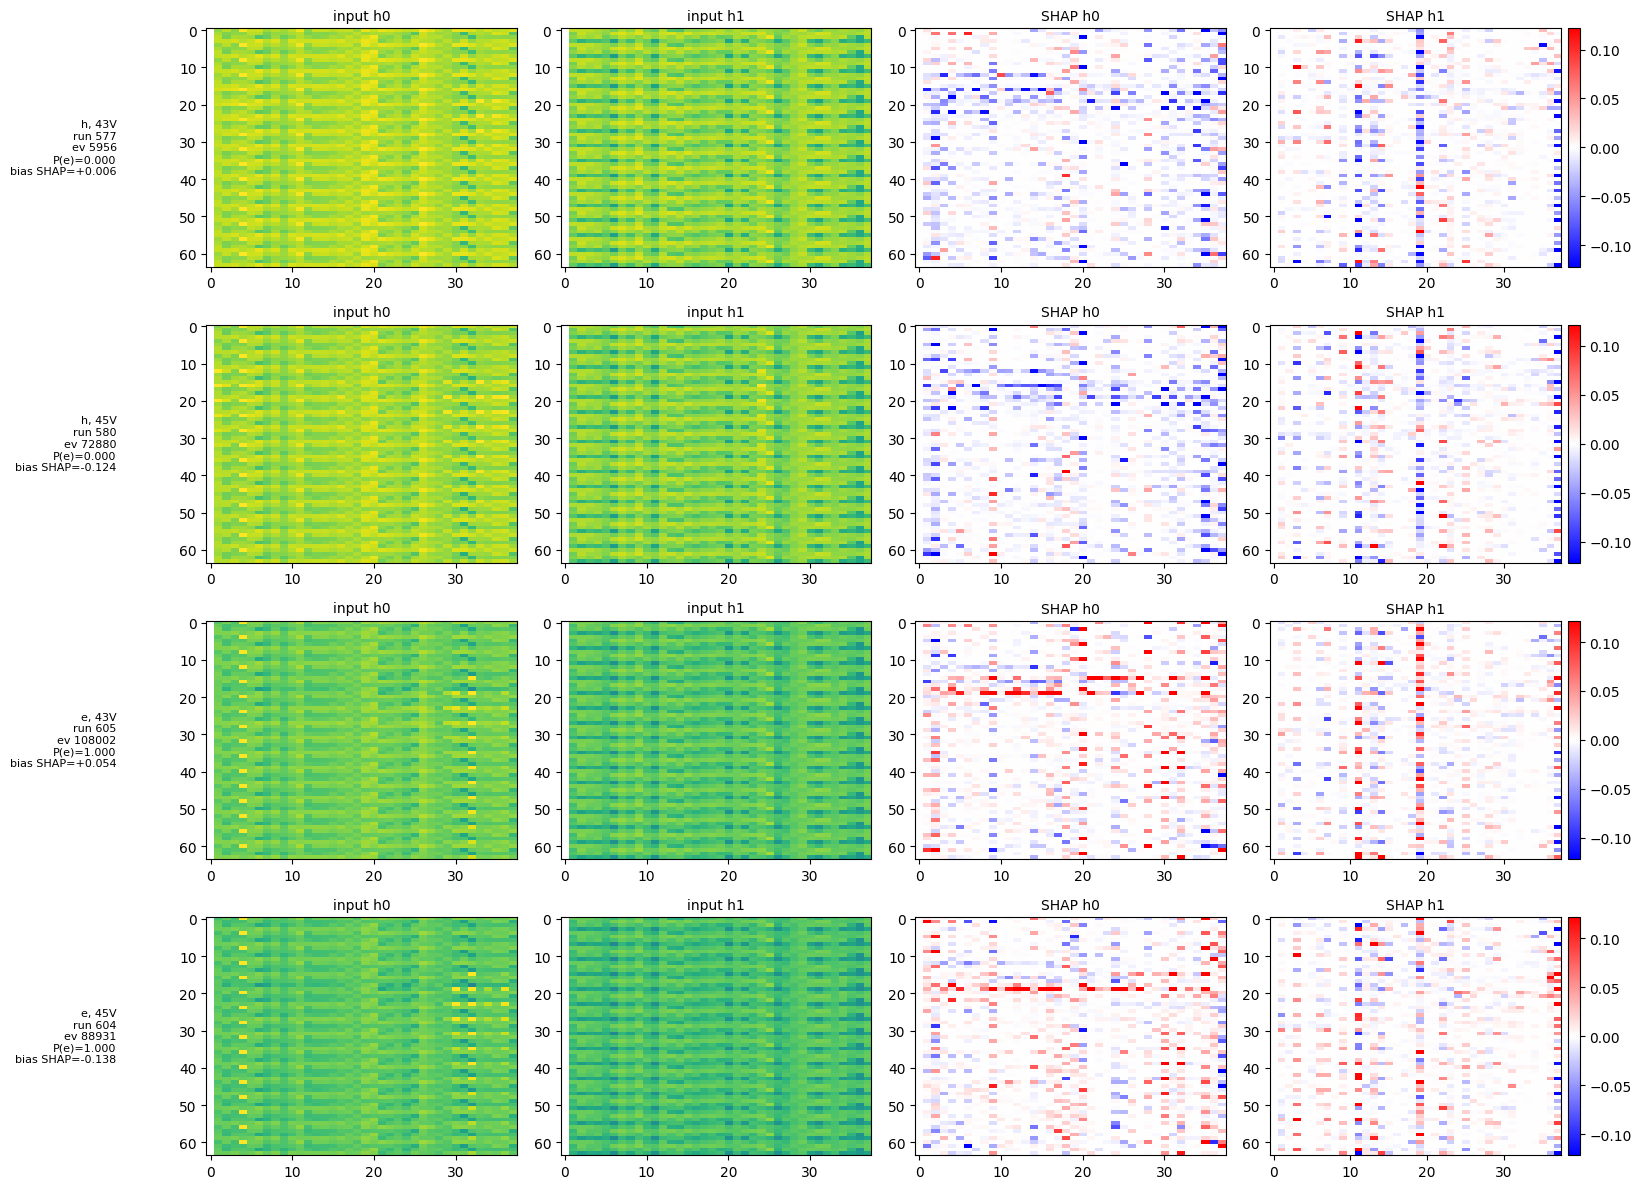

In [12]:
"""
SHAP attributions on high-confidence correctly-classified val events.

shap.TreeExplainer gives exact per-feature SHAP values for the ensemble. Values
share the 7296-feature layout, so we reshape them to (3, 64, 38) and plot beside
the raw inputs: positive (red) -> electron, negative (blue) -> hadron.
"""
import shap
from matplotlib.colors import LogNorm

explainer = shap.TreeExplainer(clf)

val_idx      = idx_val
val_particle = particle[val_idx]
val_bias_v   = bias_v[val_idx]
val_y        = y[val_idx]
val_probs    = clf.predict_proba(X_val)[:, 1]
val_preds    = (val_probs > 0.5).astype(int)
val_correct  = val_preds == val_y

# One high-confidence correct event per (particle, bias) cell
groups = [("h", 43), ("h", 45), ("e", 43), ("e", 45)]
picks  = []  # positions into the val arrays (None if no correct event)
for p, b in groups:
    mask = (val_particle == p) & (val_bias_v == b) & val_correct
    if not mask.any():
        picks.append(None); continue
    cand  = np.where(mask)[0]
    score = val_probs[cand] if p == "e" else -val_probs[cand]
    picks.append(cand[np.argmax(score)])

sel_pos = [pp for pp in picks if pp is not None]
sv = explainer.shap_values(X_val[sel_pos])
if isinstance(sv, list):          # some shap versions return [class0, class1]
    sv = sv[1]
sv = np.asarray(sv).reshape(len(sel_pos), 3, 64, 38)
smax = np.percentile(np.abs(sv[:, :2]), 99)  # symmetric color scale

fig, ax = plt.subplots(len(groups), 4, figsize=(16, 3 * len(groups)), squeeze=False)
si = 0
for gi, (p, b) in enumerate(groups):
    if picks[gi] is None:
        for j in range(4):
            ax[gi, j].text(0.5, 0.5, f"no correct {p}/{b}V events",
                           ha="center", va="center", transform=ax[gi, j].transAxes)
            ax[gi, j].set_xticks([]); ax[gi, j].set_yticks([])
        continue

    pos      = picks[gi]
    orig_idx = val_idx[pos]
    ev   = val0[orig_idx]
    vmax = max(int(np.percentile(ev, 99.5)), 2)
    norm = LogNorm(vmin=1, vmax=vmax)

    ax[gi, 0].imshow(ev[0], aspect="auto", cmap="viridis", norm=norm)
    ax[gi, 0].set_title("input h0", fontsize=10)
    ax[gi, 1].imshow(ev[1], aspect="auto", cmap="viridis", norm=norm)
    ax[gi, 1].set_title("input h1", fontsize=10)

    s = sv[si]  # (3, 64, 38)
    ax[gi, 2].imshow(s[0], aspect="auto", cmap="bwr", vmin=-smax, vmax=smax)
    ax[gi, 2].set_title("SHAP h0", fontsize=10)
    im = ax[gi, 3].imshow(s[1], aspect="auto", cmap="bwr", vmin=-smax, vmax=smax)
    ax[gi, 3].set_title("SHAP h1", fontsize=10)
    plt.colorbar(im, ax=ax[gi, 3], fraction=0.04, pad=0.02)

    ax[gi, 0].set_ylabel(
        f"{p}, {b}V\nrun {run_id[orig_idx]}\nev {orig_idx}\n"
        f"P(e)={val_probs[pos]:.3f}\nbias SHAP={s[2].sum():+.3f}",
        rotation=0, ha="right", va="center", labelpad=45, fontsize=8,
    )
    si += 1

plt.tight_layout(); plt.subplots_adjust(left=0.10); plt.show()


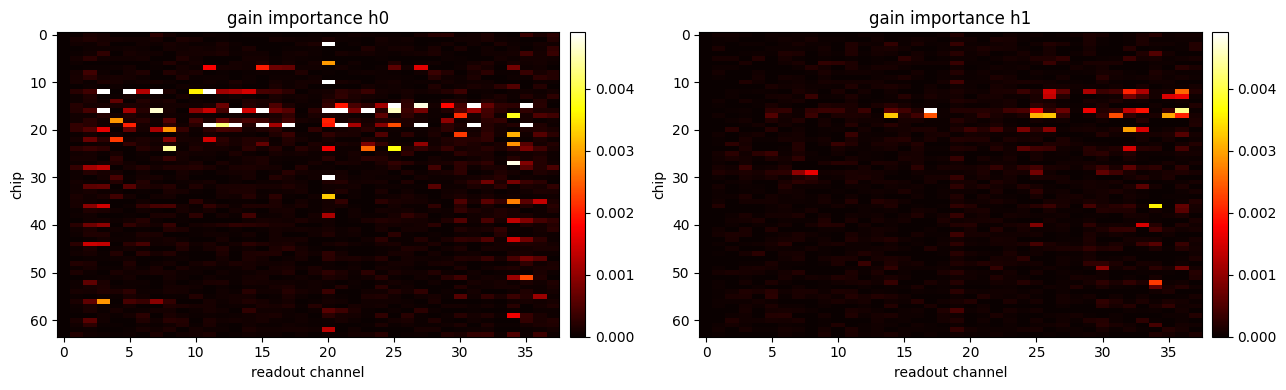

total gain on detector halves: 0.9949
total gain on bias channel:    0.0051
top detector pixel gain:       0.0517


In [13]:
"""
Global gain-based feature importance, reshaped onto the detector geometry.

XGBoost's gain importance = total loss reduction each feature contributed across
all its splits. Reshaped to (3, 64, 38), the two detector halves show which
regions the trees rely on; the bias channel is summarized separately.
"""

importances = clf.feature_importances_.reshape(3, 64, 38)  # gain, sums to 1

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
vmax = max(np.percentile(importances[:2], 99.5), 1e-9)
for h in range(2):
    im = ax[h].imshow(importances[h], aspect="auto", cmap="hot", vmin=0, vmax=vmax)
    ax[h].set_title(f"gain importance h{h}")
    ax[h].set_xlabel("readout channel"); ax[h].set_ylabel("chip")
    plt.colorbar(im, ax=ax[h], fraction=0.04, pad=0.02)
plt.tight_layout(); plt.show()

print(f"total gain on detector halves: {importances[:2].sum():.4f}")
print(f"total gain on bias channel:    {importances[2].sum():.4f}")
print(f"top detector pixel gain:       {importances[:2].max():.4f}")


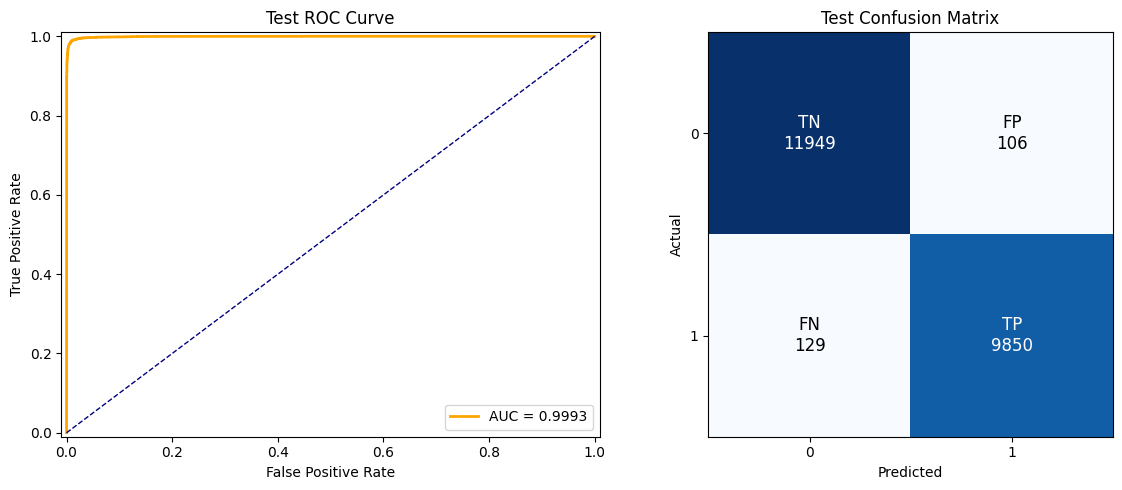

test accuracy:  0.9893
test AUC:       0.9993
confusion matrix (rows=actual, cols=predicted):
      pred=h  pred=e
act=h   11949     106
act=e     129    9850


In [12]:
"""FINAL test-set evaluation -- run once, after all model decisions are made."""

y_true = y_test
y_prob = clf.predict_proba(X_test)[:, 1]   # P(electron)
y_pred = (y_prob > 0.5).astype(int)

fpr, tpr, _   = roc_curve(y_true, y_prob)
roc_auc       = auc(fpr, tpr)
cm            = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fpr, tpr, color="orange", lw=2, label=f"AUC = {roc_auc:.4f}")
ax[0].plot([0, 1], [0, 1], "--", color="navy", lw=1)
ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("Test ROC Curve"); ax[0].legend(loc="lower right")
ax[0].set_xlim(-0.01, 1.01); ax[0].set_ylim(-0.01, 1.01)

ax[1].imshow(cm, cmap="Blues")
ax[1].set_xticks([0, 1]); ax[1].set_yticks([0, 1])
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
ax[1].set_title("Test Confusion Matrix")
cell_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        ax[1].text(j, i, f"{cell_labels[i][j]}\n{val}", ha="center", va="center",
                   color="white" if val > cm.max() / 2 else "black", fontsize=12)

plt.tight_layout(); plt.show()

print(f"test accuracy:  {(y_pred == y_true).mean():.4f}")
print(f"test AUC:       {roc_auc:.4f}")
print(f"confusion matrix (rows=actual, cols=predicted):")
print(f"      pred=h  pred=e")
print(f"act=h  {tn:6d}  {fp:6d}")
print(f"act=e  {fn:6d}  {tp:6d}")
